# Projet : Les accidents corporels routiers en France 

## Introduction

Nous voulons étudier les accidents corporels en France sur différentes années. Pour ce faire nous avons récoltés les données issus de BAAC ... Nous avons pluisuers fichiers de données composés ... 
Nous avons 3 années : 2022, 2023, 2024

Problématique : Quels facteurs influencent la gravité des accidents corporels de la route en France, peut-on prédire cette gravité en tenant compte des caractéristiques de l'accident (environnementales, géographique...) ?

In [110]:
import matplotlib.pyplot as plt

# Traitement
from src.donnees import import_donnees, renomer_cle_jointure, concatenation_annees
from src.nettoyage import recodage, mapping_renommer_colonnes, colonnes_a_supprimer, création_age_usager, jointure

# Analyse descriptive
from src.fct_carto import creation_df_carte, carte_departement

# Modelisation

In [109]:
import importlib
import src.fct_carto

importlib.reload(src.fct_carto)


<module 'src.fct_carto' from '/home/onyxia/work/Projet_pythonDS/src/fct_carto.py'>

## I - Traitement des données

Nous avons réalisé des analyses préliminaires sur nos données (disponible dans le fichier pre-processing), cela nous a permis de relever certains problèmes dans les données que nous avons pris en compte pour le nettoyage de nos données ci-dessous (comme les na, les noms de colonnes, les doublons ...)

In [18]:
donnees_completes = import_donnees()

donnees_completes["caract"][22] = renomer_cle_jointure(donnees_completes["caract"][22], "Num_Acc", "Accident_Id")

/home/onyxia/work/Projet_pythonDS/src/donnees.py:5: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')


In [19]:
# CARACTERISTIQUE
df_caract = concatenation_annees(donnees_completes, "caract")
# LIEUX
df_lieux = concatenation_annees(donnees_completes, "lieux")
# VEHICULE
df_vehicule = concatenation_annees(donnees_completes, "vehicule")
# USAGER
df_usager = concatenation_annees(donnees_completes, "usager")

In [20]:
mappings = mapping_renommer_colonnes()

In [21]:
# recodage des noms des colonnes 
df_caract_recoder = recodage(df_caract, mappings["caract"])
df_lieux_recoder = recodage(df_lieux, mappings["lieux"])
df_vehicule_recoder = recodage(df_vehicule, mappings["vehicule"])
df_usager_recoder = recodage(df_usager, mappings["usager"])

# supprimer les doublons de corrections des données dans le fichier lieux 
df_lieux_recoder = df_lieux_recoder.drop_duplicates(subset="Num_Acc", keep="last")

# age pour les usagers
df_usager_recoder = création_age_usager(df_usager_recoder)

In [22]:
df_final = jointure(df_caract_recoder, df_lieux_recoder, df_vehicule_recoder, df_usager_recoder)

In [23]:
colonnes_a_supprimer = colonnes_a_supprimer()
df_final = df_final.drop(columns=colonnes_a_supprimer, errors="ignore")
df_final = df_final.dropna(subset=["id_usager"])

In [24]:
df_final.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long', 'catr', 'voie', 'v1', 'v2',
       'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout',
       'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'id_usager', 'catu', 'grav', 'sexe', 'trajet', 'secu1',
       'secu2', 'secu3', 'age'],
      dtype='object')

In [25]:
df_final

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,manv,id_usager,catu,grav,sexe,trajet,secu1,secu2,secu3,age
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Déporté,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Manœuvre d’évitement,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
3,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 580,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39
4,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,15012,Hors agglomération,Hors intersection,...,Sans changement de direction,203 988 574,Passager,Blessé léger,Femme,Promenade - loisirs,Non déterminable,Aucun équipement,Non renseigné,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377697,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Traversant la chaussée,968 230,Conducteur,Indemne,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,24
377698,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Traversant la chaussée,968 231,Passager,Blessé hospitalisé,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,22
377699,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Sans changement de direction,968 232,Conducteur,Blessé léger,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,73
377700,202200055302,1,mars,2022,16:55,Plein jour,41,41018,En agglomération,Hors intersection,...,Sans changement de direction,968 228,Conducteur,Blessé hospitalisé,Homme,Domicile - Travail,Casque,Gants (2RM/3RM),Non renseigné,34


Certaines variables contiennent des valeurs non renseigné, pour certaines nous décidons donc de supprimer les lignes comportant des valeurs pour d'autre nous enlevons la colonne.
Pour faire notre choix nous considérons plusieurs éléments :
- enlever les lignes : si les NA sont représneter en faible quantités dans la colonnes, si la colonne est importantes. Par exemple pour la colonne gravité de l'accidnet nous avons 359 NA sur 377 638 cela représente une faible proportion des usagers de plus la colonne gravité nous est totalement indispensable pour faire nos analyses car nous voulons regarder les gravités des différents accidents 
- enlever les colonnes : si il y a beaucoup de NA et que la colonne n'est pas forcement pertinentes pour nos analyses 

In [26]:
# suppression des NA 
df_final = df_final.dropna(subset=["grav"])

## II - Analyse Descriptive des accidents corporels en France

### 4. Dans quel département français les accidents sont-ils les plus graves ? Un peu de cartographie

Nous souhaitons voir si certaines régions (ou departements) ont plus d'accidents grave ... ?
Par accident, il peut y avoir plusiuers victime, nous considérons donc le nombre de victime et non le nombre d'accident 

In [27]:
# nombre d'accident
print("nombre d'accidents : ", df_final["Num_Acc"].nunique())
# nombre de victime 
print("nombre de victimes : ", df_final["id_usager"].nunique())

nombre d'accidents :  164526
nombre de victimes :  377279


In [28]:
# recupération du nombre de victime par departement et gravité
df_victime_dep = df_final.groupby("dep").size().reset_index(name="nb").sort_values(by="nb")
print(df_victime_dep)

     dep     nb
100  975     13
104  986     59
102  977     60
103  978    191
21    23    324
..   ...    ...
94    94  15063
12    13  16149
92    92  16468
93    93  18759
75    75  30565

[107 rows x 2 columns]


comme on peut le voir ci-dessus, le nombre d'accident par departement est très inégale, on observe notamment beaucoup d'accidnet dans les départemetn en ile de France, cela peut s'expiquer du fait qu'il ya plus d'habitants aussi 
Du a cela, nous allons étudier la proportion des blessures d'accident plutot que le nombre qui est trop disproportionné en fonction des département.

In [31]:
print(df_final["grav"].unique())

['Blessé hospitalisé' 'Indemne' 'Blessé léger' 'Tué']


In [42]:
df_victimes_tot = creation_df_carte(df_final)

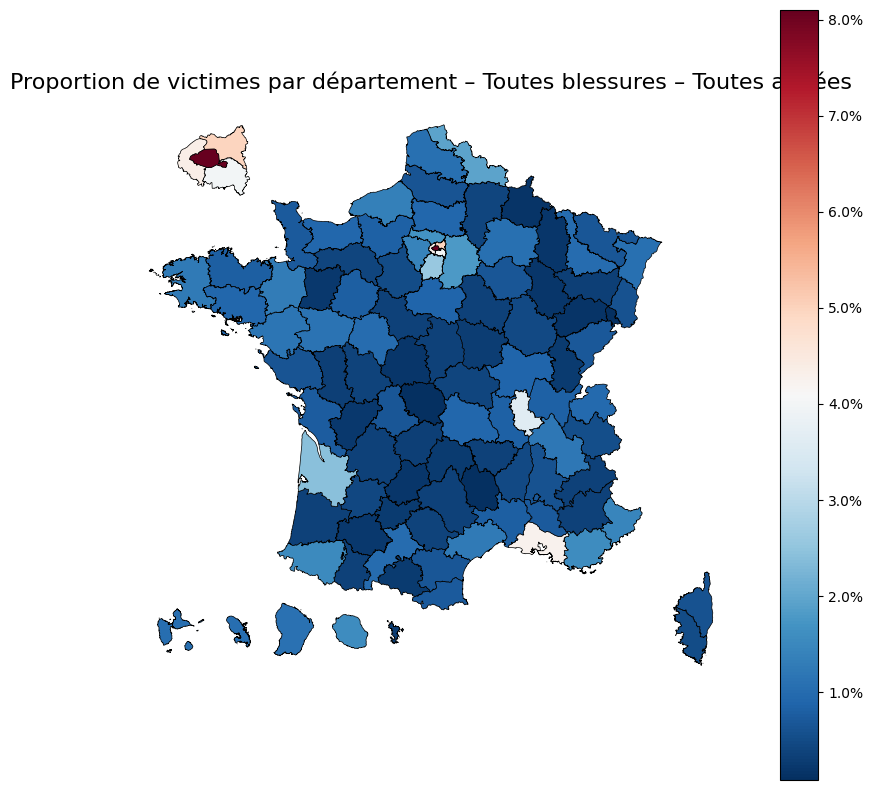

In [44]:
carte_departement(df_victimes_tot)

In [54]:
df_victimes_blessure = creation_df_carte(df_final, blessure=True)

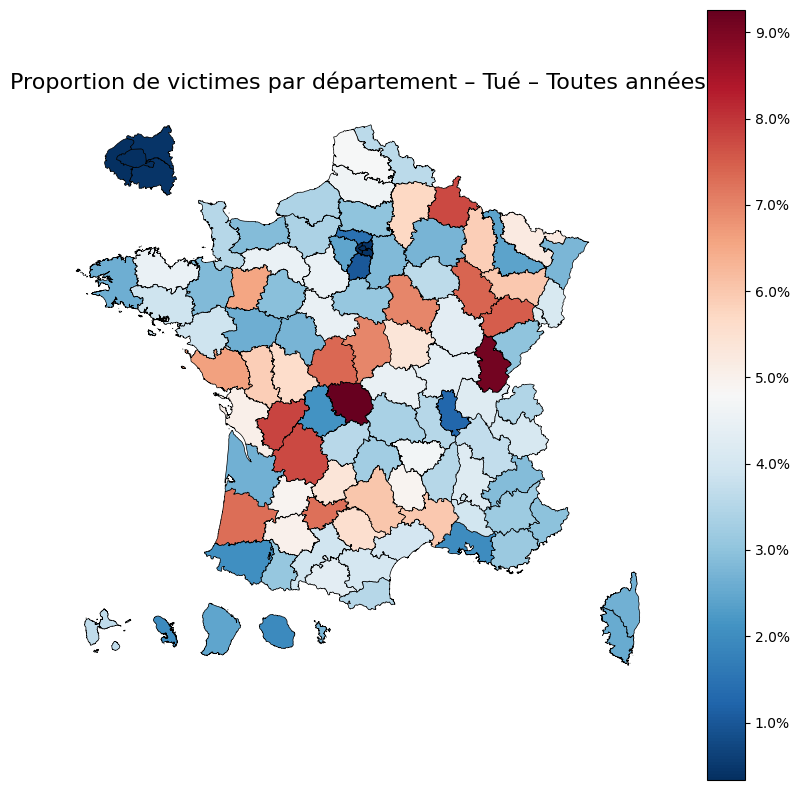

In [ ]:
carte_departement(df_victimes_blessure, blessure="Tué")

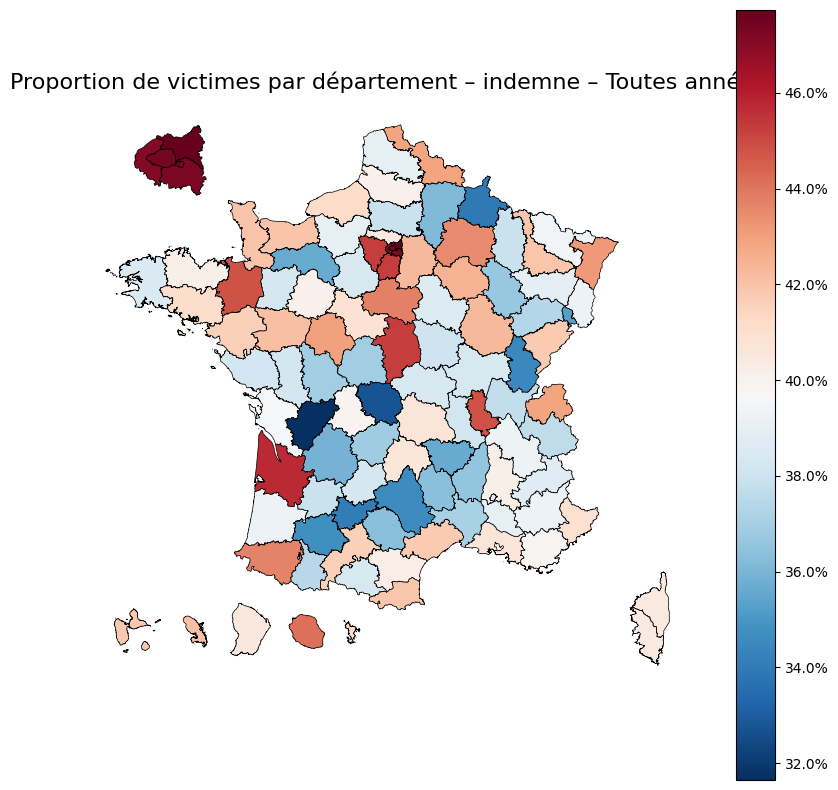

In [74]:
carte_departement(df_victimes_blessure, blessure="indemne")

Les victimes tués par un accdient sont une faible proportion des victimes, ou on en voit le plus dans la diagonal du vide 
En revanche, les accidents indemne sont plus vers le nord 
comparaison année à faire 

In [64]:
df_victimes_an = creation_df_carte(df_final, an=True)

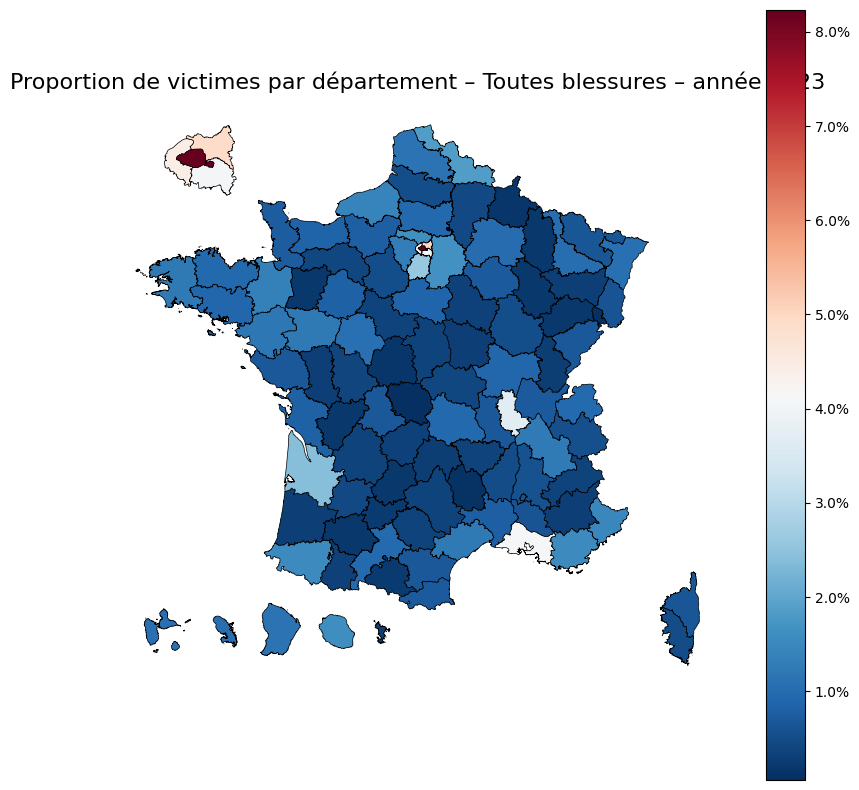

In [75]:
carte_departement(df_victimes_an, an=2023)

In [76]:
df_victimes_an_blessure = creation_df_carte(df_final, an=True, blessure=True)

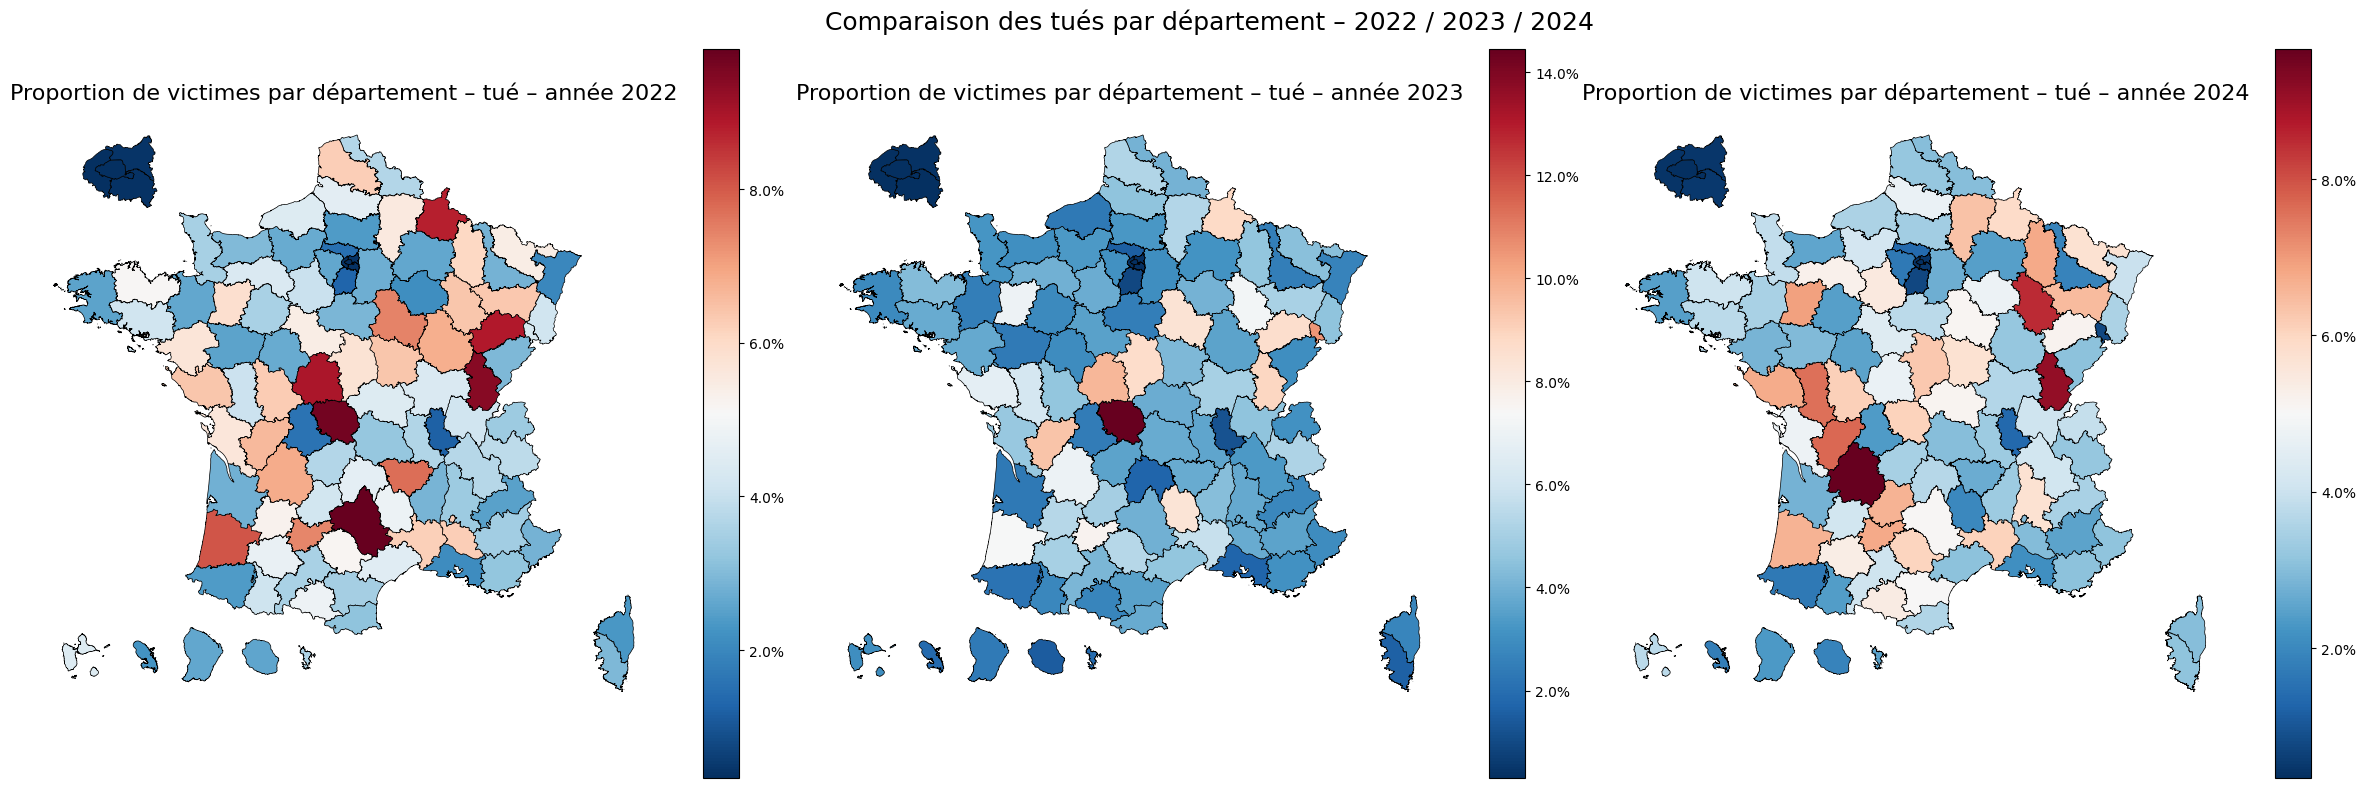

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

carte_departement(df_victimes_an_blessure, blessure="tué", an=2022, ax=axes[0])
carte_departement(df_victimes_an_blessure, blessure="tué", an=2023, ax=axes[1])
carte_departement(df_victimes_an_blessure, blessure="tué", an=2024, ax=axes[2])

fig.suptitle("Comparaison des tués par département – 2022 / 2023 / 2024", fontsize=18)
plt.tight_layout()
plt.show()

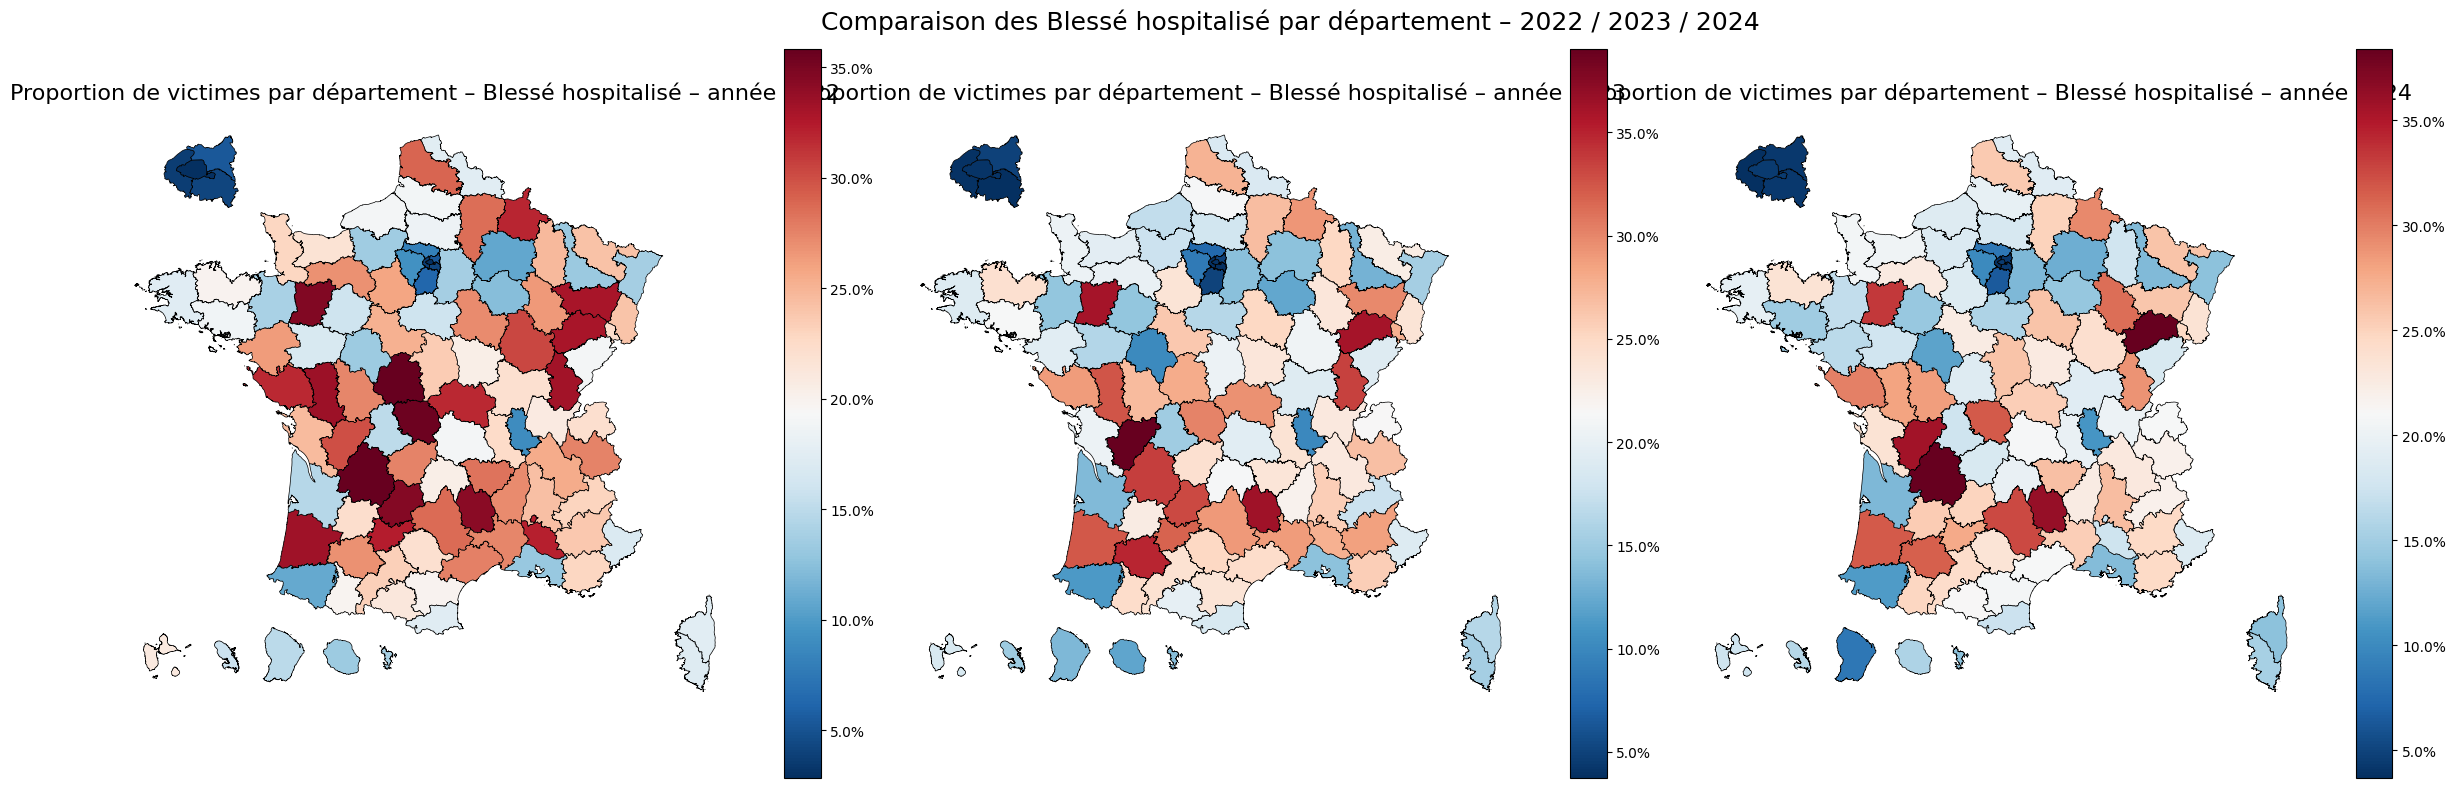

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

carte_departement(df_victimes_an_blessure, blessure="Blessé hospitalisé", an=2022, ax=axes[0])
carte_departement(df_victimes_an_blessure, blessure="Blessé hospitalisé", an=2023, ax=axes[1])
carte_departement(df_victimes_an_blessure, blessure="Blessé hospitalisé", an=2024, ax=axes[2])

fig.suptitle("Comparaison des Blessé hospitalisé par département – 2022 / 2023 / 2024", fontsize=18)
plt.tight_layout()
plt.show()


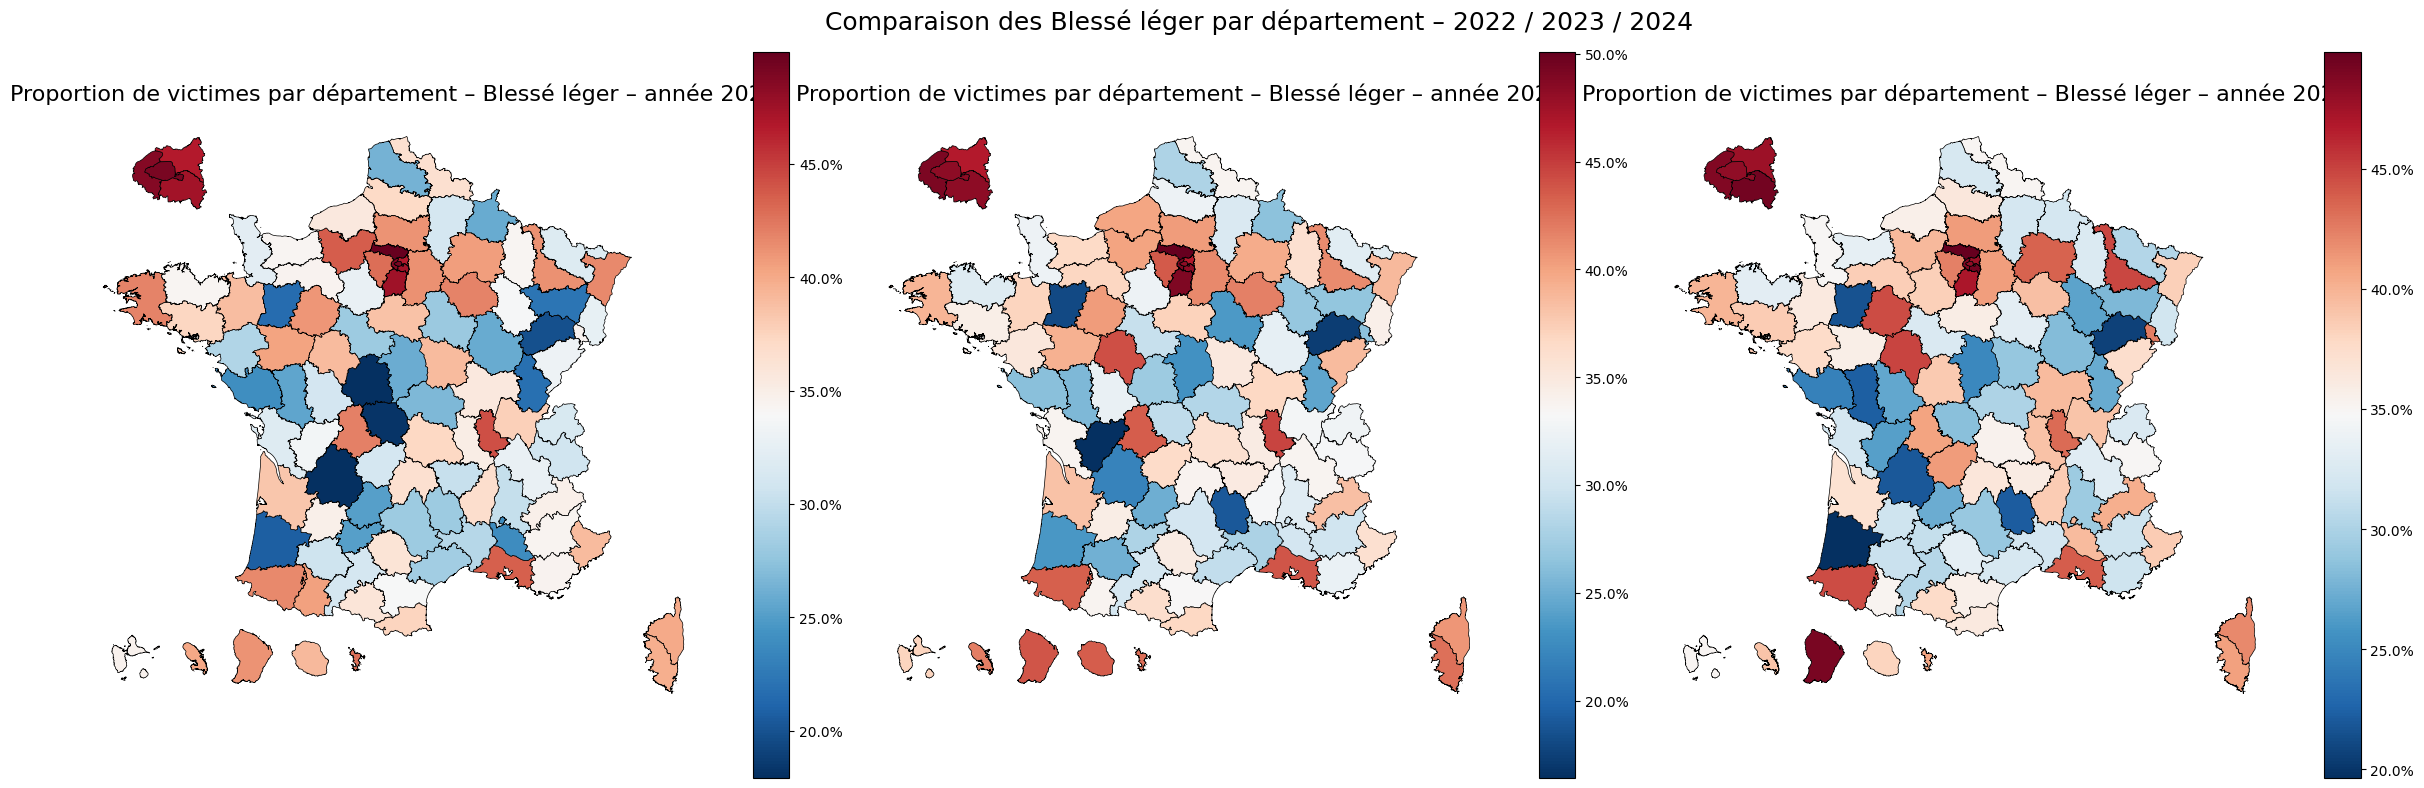

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

carte_departement(df_victimes_an_blessure, blessure="Blessé léger", an=2022, ax=axes[0])
carte_departement(df_victimes_an_blessure, blessure="Blessé léger", an=2023, ax=axes[1])
carte_departement(df_victimes_an_blessure, blessure="Blessé léger", an=2024, ax=axes[2])

fig.suptitle("Comparaison des Blessé léger par département – 2022 / 2023 / 2024", fontsize=18)
plt.tight_layout()
plt.show()

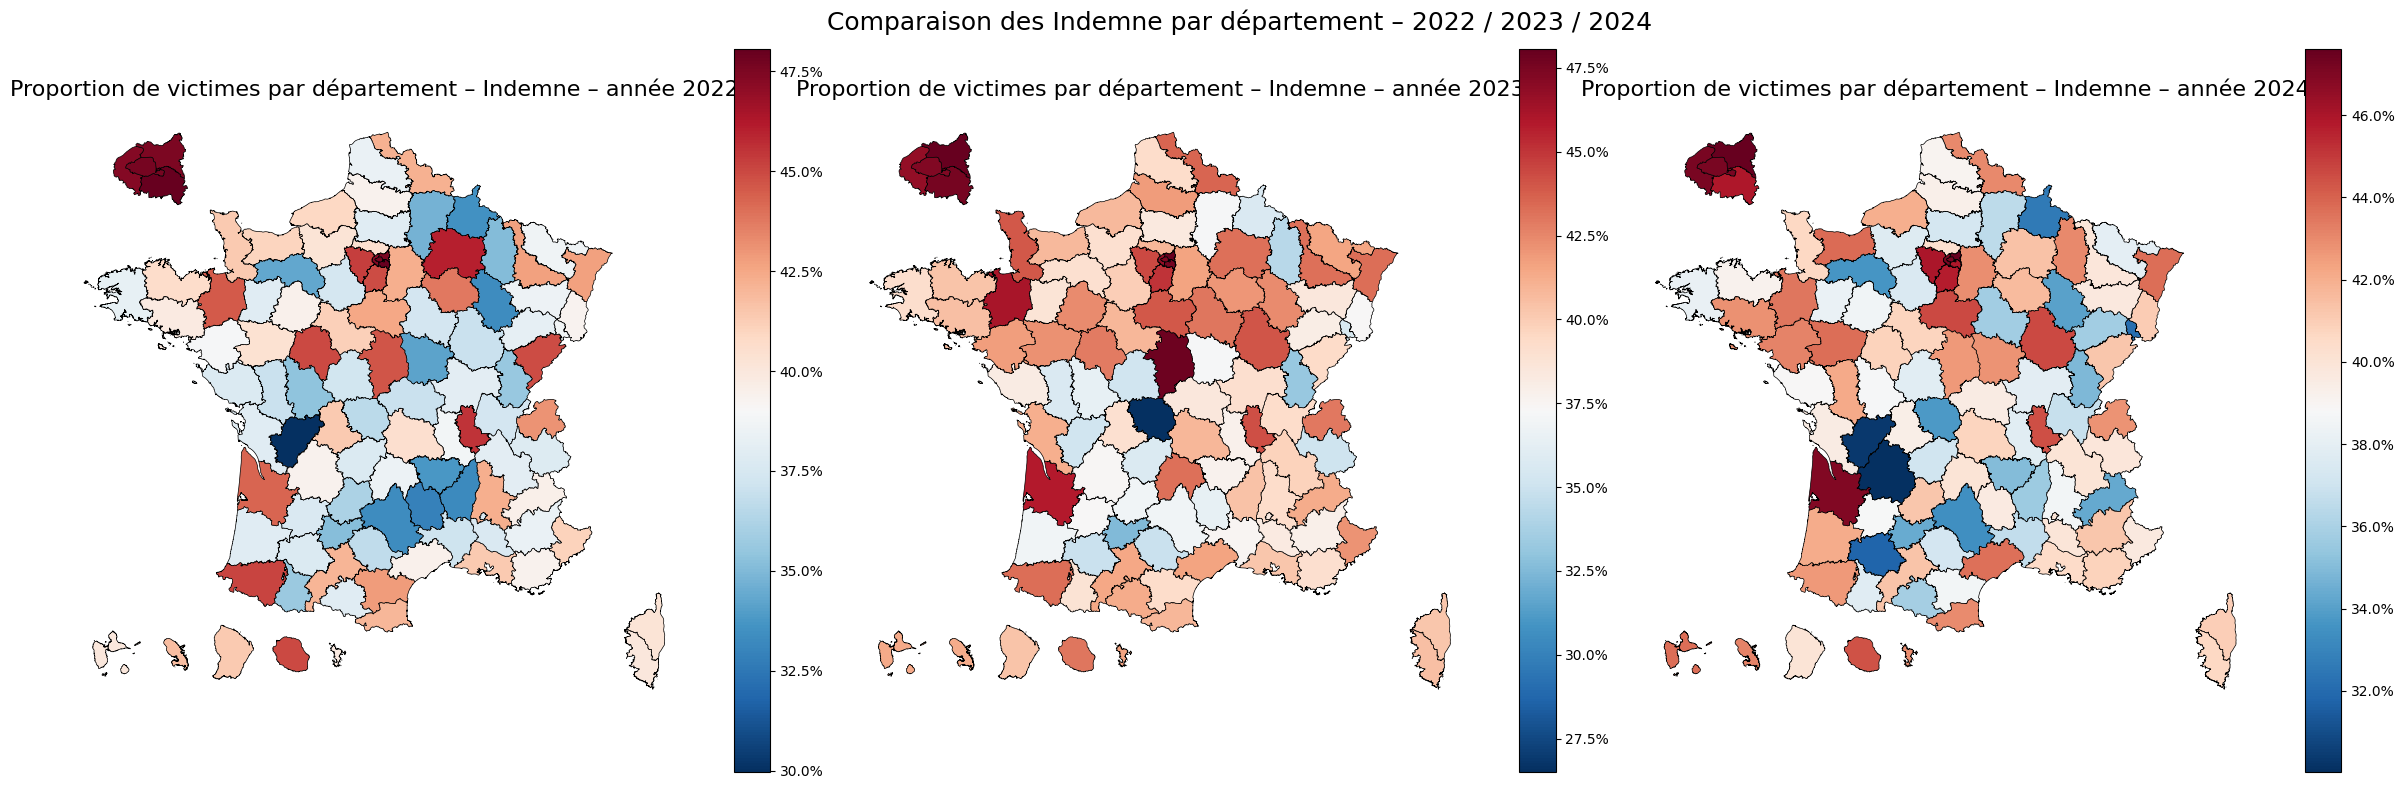

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

carte_departement(df_victimes_an_blessure, blessure="Indemne", an=2022, ax=axes[0])
carte_departement(df_victimes_an_blessure, blessure="Indemne", an=2023, ax=axes[1])
carte_departement(df_victimes_an_blessure, blessure="Indemne", an=2024, ax=axes[2])

fig.suptitle("Comparaison des Indemne par département – 2022 / 2023 / 2024", fontsize=18)
plt.tight_layout()
plt.show()